# LoRA Fine-Tuning — RoBERTa-base on SST-2

Faithful from-scratch reimplementation of **LoRA: Low-Rank Adaptation of Large Language Models**
([arXiv:2106.09685](https://arxiv.org/abs/2106.09685), Hu et al. 2021).

We implement the LoRA layer directly from the paper's equations (no `peft` library), inject it into
RoBERTa-base's attention `Wq`/`Wv` matrices, and compare against **full fine-tuning** and a
**head-only** baseline on GLUE SST-2.

### Method (paper §4.1)
For a frozen pre-trained weight $W_0 \in \mathbb{R}^{d\times k}$, LoRA constrains the update to a low-rank
decomposition:
$$h = W_0 x + \Delta W x = W_0 x + \frac{\alpha}{r} B A x,\quad B\in\mathbb{R}^{d\times r},\ A\in\mathbb{R}^{r\times k},\ r\ll\min(d,k)$$
- **A** uses a random Gaussian init, **B** is initialized to **zero**, so $\Delta W = BA = 0$ at the start of training.
- $\Delta W x$ is scaled by $\alpha/r$; $\alpha$ is fixed (not tuned).

### Applying to Transformer (paper §4.2)
Only the attention weights are adapted; the MLP is frozen. The paper's main configuration adapts
**$W_q$ and $W_v$** with `rq = rv = 8`, `α = 8` for RoBERTa-base (Table 9).

### Deviations from the paper (for Colab feasibility — documented up front)
| Item | Paper (Table 9) | Here | Why |
|------|-----------------|------|-----|
| Epochs (SST-2) | 60 | **3** (configurable) | 60 epochs × 67k examples is many hours on a T4; SST-2 converges in a few epochs |
| Max seq length | 512 | **128** | SST-2 is single short sentences; 128 covers them and is ~4× faster |
| Full-FT learning rate | not in Table 9 (reused prior work) | **1e-5** | standard RoBERTa GLUE full-FT LR |
| Random seeds | median over 5 | **1** | single run for a demo |

Everything else (LoRA math, A/B init, α/r scaling, Wq/Wv targeting, r=8, α=8, AdamW, linear-decay
with 0.06 warmup ratio, LR 5e-4 for LoRA) follows Table 9 verbatim.

## 0. Setup

In [9]:
# Colab: install dependencies (skip if already present)
!pip -q install "transformers>=4.40" "datasets>=2.19" "evaluate>=0.4" scikit-learn matplotlib torch

In [10]:
import math, time, copy, json
from dataclasses import dataclass, field

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          get_linear_schedule_with_warmup)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42); np.random.seed(42)
print('device:', device)
if device.type == 'cuda':
    print('gpu   :', torch.cuda.get_device_name(0))

device: cuda
gpu   : NVIDIA A100-SXM4-80GB


## 1. Configuration

Paper-faithful defaults for RoBERTa-base + SST-2 from Table 9, with the Colab deviations noted above.

In [11]:
@dataclass
class Config:
    model_name: str = 'roberta-base'
    task: str = 'sst2'              # GLUE SST-2
    num_labels: int = 2
    # ----- LoRA (Table 9: rq = rv = 8, alpha = 8) -----
    lora_r: int = 8
    lora_alpha: int = 8
    lora_dropout: float = 0.0
    lora_targets: tuple = ('query', 'value')   # Wq, Wv (paper §4.2)
    lora_init_std: float = 0.02     # paper says 'random Gaussian' w/o std; 0.02 = RoBERTa init std
    # ----- optimization (Table 9) -----
    lora_lr: float = 5e-4           # Table 9 SST-2 LoRA LR
    full_lr: float = 1e-5           # standard full-FT LR (not in Table 9)
    head_lr: float = 1e-3           # head-only baseline
    weight_decay: float = 0.0
    warmup_ratio: float = 0.06      # Table 9
    batch_size: int = 16            # Table 9 SST-2
    epochs: int = 3                 # DEVIATION: paper 60
    max_seq_len: int = 128          # DEVIATION: paper 512
    # ----- demo speed knobs -----
    train_subset: int = 0           # 0 = full SST-2; else cap # train examples
    eval_subset: int = 0            # 0 = full dev set

cfg = Config()
cfg

Config(model_name='roberta-base', task='sst2', num_labels=2, lora_r=8, lora_alpha=8, lora_dropout=0.0, lora_targets=('query', 'value'), lora_init_std=0.02, lora_lr=0.0005, full_lr=1e-05, head_lr=0.001, weight_decay=0.0, warmup_ratio=0.06, batch_size=16, epochs=3, max_seq_len=128, train_subset=0, eval_subset=0)

## 2. LoRA layer (from scratch — paper §4.1)

`LoRALinear` wraps a frozen `nn.Linear` and adds the low-rank path. With $W \in \mathbb{R}^{out\times in}$,
we keep $A \in \mathbb{R}^{r\times in}$ and $B \in \mathbb{R}^{out\times r}$ so that $\Delta W = B A \in \mathbb{R}^{out\times in}$,
matching $W$'s shape. The forward pass is $y = W_0 x + \frac{\alpha}{r}\,(x A^\top) B^\top$.

In [ ]:
class LoRALinear(nn.Module):
    """기존 nn.Linear(=사전학습된 W0)를 '감싸서' 학습 가능한 저차원(low-rank) 업데이트를 더해주는 레이어.

    핵심 아이디어 (논문 eq.3):
        원래 출력  : h = W0 @ x
        LoRA 출력  : h = W0 @ x + (alpha/r) * (B @ A) @ x
    즉, W0는 그대로 얼리고(freeze), 그 옆에 B@A 라는 '작은 우회로'만 새로 학습한다.
    W0를 직접 바꾸지 않기 때문에 원본 가중치 손실 없이, 아주 적은 파라미터만 추가로 학습할 수 있다.
    """
    def __init__(self, base: nn.Linear, r: int, alpha: int,
                 dropout: float = 0.0, init_std: float = 0.02):
        super().__init__()
        assert r > 0
        # ── (1) 원본 Linear(W0)를 그대로 보관하되 '얼린다' ─────────────────────
        # base 는 RoBERTa가 사전학습으로 얻은 query/value 가중치. 이걸 학습에서 제외(freeze)해야
        # LoRA의 목적(=대부분 파라미터를 고정, 극소수만 학습)이 성립한다.
        self.base = base
        self.base.weight.requires_grad_(False)          # W0의 gradient 계산/업데이트 중단
        if self.base.bias is not None:
            self.base.bias.requires_grad_(False)        # bias도 동결

        in_f, out_f = base.in_features, base.out_features   # W0 의 모양은 (out_f, in_f)
        self.r, self.alpha = r, alpha

        # ── (2) 스케일 계수 alpha/r ────────────────────────────────────────────
        # 논문은 (B@A)x 에 alpha/r 을 곱한다. r(rank)을 바꿔도 업데이트의 크기가 비슷하게 유지되도록
        # 정규화하는 장치. 덕분에 r을 바꿀 때마다 learning rate를 다시 튜닝할 필요가 줄어든다.
        # alpha 는 고정값으로 두고 따로 튜닝하지 않는다(논문 §4.1).
        self.scaling = alpha / r

        # ── (3) 저차원 행렬 A, B 정의 ──────────────────────────────────────────
        # W0 가 (out_f, in_f) 이므로 ΔW = B@A 도 (out_f, in_f) 가 되어야 더할 수 있다.
        #   A: (r, in_f)   B: (out_f, r)   →   B@A: (out_f, in_f)  ✔ 모양 일치
        # 학습 파라미터 수는 r*(in_f+out_f) 로, 원본 in_f*out_f 보다 r이 작을수록 훨씬 적다.
        self.lora_A = nn.Parameter(torch.empty(r, in_f))     # 학습 대상
        self.lora_B = nn.Parameter(torch.zeros(out_f, r))    # 학습 대상, 0으로 초기화

        # ── (4) 초기화: A는 가우시안, B는 0 (논문 §4.1) ────────────────────────
        # 왜 B=0 인가? 학습 시작 순간 ΔW = B@A = 0 이 되어, LoRA를 막 붙인 모델이
        # '원본 사전학습 모델과 완전히 동일'하게 출발한다. 즉 LoRA가 처음엔 아무 영향도 주지 않고,
        # 학습이 진행되며 B가 0에서 서서히 자라나 필요한 업데이트만 배운다. (안정적인 출발점)
        # A는 0이면 gradient가 흐르지 않으므로(B도 0이라 둘 다 0이면 학습 불가) 가우시안으로 깨운다.
        # 논문은 std를 명시하지 않아 RoBERTa 표준 init std(0.02)를 사용.
        nn.init.normal_(self.lora_A, mean=0.0, std=init_std)
        # lora_B 는 위에서 이미 zeros 로 만들었으므로 그대로 둔다.

        # ── (5) (선택) LoRA 경로에만 적용하는 dropout ──────────────────────────
        # 입력 x에 dropout을 걸어 저차원 업데이트의 과적합을 완화. 0이면 항등(Identity).
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        # ── 순전파: 원본 경로 + LoRA 우회로 ───────────────────────────────────
        out = self.base(x)                              # ① 원본: W0 @ x (+ bias). gradient는 안 흐름.
        # ② LoRA 경로: (B@A)@x 를 계산. 메모리 효율을 위해 큰 행렬 B@A를 먼저 만들지 않고
        #    x를 A로, 다시 B로 순차 투영한다.  (x @ A^T) → (·, r) → @ B^T → (·, out_f)
        #    A:(r,in_f) 이므로 x@A^T 는 in_f→r 로 '압축', 다시 B^T 로 r→out_f 로 '복원'.
        lora = (self.dropout(x) @ self.lora_A.t()) @ self.lora_B.t()
        # ③ 스케일을 곱해 원본 출력에 더한다.  h = W0 x + (alpha/r) (B A) x
        return out + self.scaling * lora

    def extra_repr(self):
        # print(model) 했을 때 r/alpha/scaling 이 보이도록(디버깅 편의)
        return f'r={self.r}, alpha={self.alpha}, scaling={self.scaling:.3f}'

## 3. Inject LoRA into RoBERTa attention (`Wq`, `Wv`)

RoBERTa self-attention exposes `query`, `key`, `value` as `nn.Linear`. We replace `query` and `value`
with `LoRALinear` (paper's main config), leaving `key`, the attention output, and all MLP weights frozen.

In [ ]:
def inject_lora(model, cfg: Config):
    """모델 안의 특정 nn.Linear(query, value)들을 LoRALinear 로 '치환'한다.

    왜 이렇게 하나?
      RoBERTa는 수십 개의 Transformer 블록으로 되어 있고, 각 블록의 self-attention 안에
      query/key/value 라는 nn.Linear 가 있다. 논문 §4.2는 이 중 Wq, Wv 에만 LoRA를 붙이고
      나머지(key, attention output, MLP 전체)는 그대로 둔다 → 가장 파라미터 효율적인 구성.
      따라서 모델 전체를 훑으며 이름이 'query'/'value' 인 Linear 를 찾아 그 자리에 LoRALinear 를 끼운다.
    """
    n_injected = 0
    # model.modules() : 모델 안의 모든 하위 모듈을 재귀적으로 순회 (각 attention 블록 포함)
    for parent in model.modules():
        # named_children() : 바로 아래 직속 자식들만. (attr=이름, child=모듈)
        # list(...) 로 스냅샷을 떠두는 이유: 순회 도중 setattr 로 자식을 교체하면
        # 원본 순회 객체를 직접 바꾸게 되어 위험하므로, 미리 복사본을 만들어 안전하게 교체.
        for attr, child in list(parent.named_children()):
            # 이름이 타깃(query/value)이고 실제로 Linear 인 경우에만 교체
            if attr in cfg.lora_targets and isinstance(child, nn.Linear):
                # 기존 Linear(child=W0)를 LoRALinear로 감싸서 같은 자리에 다시 꽂는다.
                # 부모 입장에서는 parent.query 가 nn.Linear → LoRALinear 로 바뀐 것뿐이라
                # forward 흐름은 그대로 유지되면서 내부 계산만 W0x → W0x+(α/r)BAx 로 바뀐다.
                setattr(parent, attr, LoRALinear(child, cfg.lora_r, cfg.lora_alpha,
                                                 cfg.lora_dropout, cfg.lora_init_std))
                n_injected += 1
    return n_injected   # 끼워진 LoRA 레이어 수 (= 블록수 × 2, query/value)


def mark_trainable(model, mode: str):
    """어떤 파라미터를 학습할지(requires_grad) 모드별로 설정.

      'full' : 전체 파라미터 학습 (= 일반적인 full fine-tuning, 비교용 baseline)
      'lora' : 사전학습 가중치는 모두 동결, LoRA의 A·B 와 분류 헤드만 학습 (논문 방식)
      'head' : 사전학습 가중치 전부 동결, 분류 헤드만 학습 (하한선 baseline)
    """
    if mode == 'full':
        # 모든 파라미터를 학습 대상으로 → 125M 전부 업데이트
        for p in model.parameters():
            p.requires_grad_(True)
        return

    # 'lora' 와 'head' 는 공통적으로 "일단 전부 얼린다"에서 출발
    for p in model.parameters():
        p.requires_grad_(False)

    # 분류 헤드(classifier)는 항상 학습해야 한다.
    # 이유: SST-2용 분류 헤드는 사전학습 체크포인트에 없고 '랜덤 초기화'된 새 레이어다.
    #       (앞 셀의 LOAD REPORT에서 classifier.* 가 MISSING 으로 뜬 것이 바로 이것)
    #       이걸 학습 안 하면 무작위 헤드 그대로라 분류가 불가능하므로, 모든 모드에서 켠다.
    for n, p in model.named_parameters():
        if 'classifier' in n:
            p.requires_grad_(True)

    if mode == 'lora':
        # LoRA 모드에서는 추가로 A·B 만 학습 대상으로 켠다.
        # 이름에 'lora_A'/'lora_B' 가 들어간 파라미터가 우리가 §2에서 만든 그 학습 행렬들이다.
        for n, p in model.named_parameters():
            if 'lora_A' in n or 'lora_B' in n:
                p.requires_grad_(True)
    # 'head' 모드면 여기서 끝 → 분류 헤드만 학습, 인코더는 완전 동결.


def count_params(model):
    """학습 가능한 파라미터 수와 전체 파라미터 수를 센다. (효율성 비교의 핵심 지표)"""
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)  # requires_grad=True 만 합산
    total = sum(p.numel() for p in model.parameters())                          # 전체
    return trainable, total

## 4. Data — GLUE SST-2

Binary sentiment classification. We use the validation split for evaluation (the GLUE test labels are hidden).

In [14]:
tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)
# GLUE moved to the 'nyu-mll/glue' namespace on the HF Hub; the bare 'glue'
# id no longer resolves on recent `datasets` versions. Fall back if needed.
try:
    raw = load_dataset('nyu-mll/glue', cfg.task)
except Exception:
    raw = load_dataset('glue', cfg.task, trust_remote_code=True)

def preprocess(batch):
    return tokenizer(batch['sentence'], truncation=True, max_length=cfg.max_seq_len)

tokenized = raw.map(preprocess, batched=True)
tokenized = tokenized.remove_columns(['sentence', 'idx']).rename_column('label', 'labels')
# NOTE: we intentionally do NOT call set_format('torch'). On Colab the datasets
# TorchFormatter tries `from torchvision.io import VideoReader`, which crashes on
# version mismatches. DataCollatorWithPadding already returns torch tensors, so
# leaving the dataset in plain (python) format avoids that import entirely.
keep = ['input_ids', 'attention_mask', 'labels']
tokenized = tokenized.remove_columns(
    [c for c in tokenized['train'].column_names if c not in keep])

train_ds = tokenized['train']
eval_ds = tokenized['validation']
if cfg.train_subset:
    train_ds = train_ds.select(range(min(cfg.train_subset, len(train_ds))))
if cfg.eval_subset:
    eval_ds = eval_ds.select(range(min(cfg.eval_subset, len(eval_ds))))
print(f'train={len(train_ds)}  eval={len(eval_ds)}')

from transformers import DataCollatorWithPadding
collator = DataCollatorWithPadding(tokenizer, return_tensors='pt')
from torch.utils.data import DataLoader
train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, collate_fn=collator)
eval_loader = DataLoader(eval_ds, batch_size=64, shuffle=False, collate_fn=collator)

# sanity check: one batch yields torch tensors
_b = next(iter(eval_loader))
print({k: tuple(v.shape) for k, v in _b.items()})

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

train=67349  eval=872
{'labels': (64,), 'input_ids': (64, 48), 'attention_mask': (64, 48)}


## 5. Training & evaluation loop

AdamW + linear LR decay with a 0.06 warmup ratio (Table 9). Returns per-epoch dev accuracy plus
training time and peak GPU memory.

In [15]:
@torch.no_grad()
def evaluate(model):
    model.eval()
    correct = total = 0
    for batch in eval_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        logits = model(**batch).logits
        preds = logits.argmax(-1)
        correct += (preds == batch['labels']).sum().item()
        total += batch['labels'].numel()
    return correct / total

def build_model(mode: str):
    """Fresh model for a given mode in {'lora','full','head'}."""
    model = AutoModelForSequenceClassification.from_pretrained(
        cfg.model_name, num_labels=cfg.num_labels)
    if mode == 'lora':
        n = inject_lora(model, cfg)
        print(f'  injected LoRA into {n} linear layers (Wq, Wv per attention block)')
    mark_trainable(model, mode)
    return model.to(device)

def train_one(mode: str, lr: float):
    model = build_model(mode)
    trn, tot = count_params(model)
    print(f'[{mode}] trainable={trn:,} / total={tot:,}  ({100*trn/tot:.3f}%)')
    optim = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad],
                              lr=lr, weight_decay=cfg.weight_decay)
    steps = len(train_loader) * cfg.epochs
    sched = get_linear_schedule_with_warmup(optim, int(cfg.warmup_ratio * steps), steps)
    if device.type == 'cuda':
        torch.cuda.reset_peak_memory_stats(); torch.cuda.empty_cache()
    history = []
    t0 = time.time()
    for ep in range(cfg.epochs):
        model.train()
        for batch in train_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            loss = model(**batch).loss
            loss.backward()
            optim.step(); sched.step(); optim.zero_grad()
        acc = evaluate(model)
        history.append(acc)
        print(f'  epoch {ep+1}/{cfg.epochs}  dev_acc={acc:.4f}')
    elapsed = time.time() - t0
    peak_mem = (torch.cuda.max_memory_allocated() / 1e9) if device.type == 'cuda' else 0.0
    return {'mode': mode, 'trainable': trn, 'total': tot, 'history': history,
            'final_acc': history[-1], 'time_s': elapsed, 'peak_mem_gb': peak_mem}

## 6. Run the three configurations

- **LoRA** — `rq=rv=8`, `α=8`, LR 5e-4 (Table 9)
- **Full fine-tuning** — all 125M params, LR 1e-5
- **Head-only** — classifier head only (frozen-encoder lower bound), LR 1e-3

In [16]:
results = {}
print('=== LoRA ===');      results['lora'] = train_one('lora', cfg.lora_lr)
print('=== Full FT ===');   results['full'] = train_one('full', cfg.full_lr)
print('=== Head-only ==='); results['head'] = train_one('head', cfg.head_lr)

import pandas as pd
summary = pd.DataFrame([
    {'config': r['mode'],
     'trainable_params': r['trainable'],
     '% of full': 100 * r['trainable'] / results['full']['total'],
     'final_dev_acc': r['final_acc'],
     'train_time_s': round(r['time_s'], 1),
     'peak_mem_GB': round(r['peak_mem_gb'], 2)}
    for r in results.values()
])
summary

=== LoRA ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  injected LoRA into 24 linear layers (Wq, Wv per attention block)
[lora] trainable=887,042 / total=124,942,082  (0.710%)
  epoch 1/3  dev_acc=0.9278
  epoch 2/3  dev_acc=0.9300
  epoch 3/3  dev_acc=0.9369
=== Full FT ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

[full] trainable=124,647,170 / total=124,647,170  (100.000%)
  epoch 1/3  dev_acc=0.9415
  epoch 2/3  dev_acc=0.9392
  epoch 3/3  dev_acc=0.9427
=== Head-only ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[head] trainable=592,130 / total=124,647,170  (0.475%)
  epoch 1/3  dev_acc=0.8383
  epoch 2/3  dev_acc=0.8268
  epoch 3/3  dev_acc=0.8211


,config,trainable_params,% of full,final_dev_acc,train_time_s,peak_mem_GB
0,lora,887042,0.711642,0.936927,413.9,1.52
1,full,124647170,100.000000,0.942661,450.2,3.06
2,head,592130,0.475045,0.821101,163.0,1.16


## 7. Visualization

LoRA's headline claim: comparable accuracy at a tiny fraction of the trainable parameters.

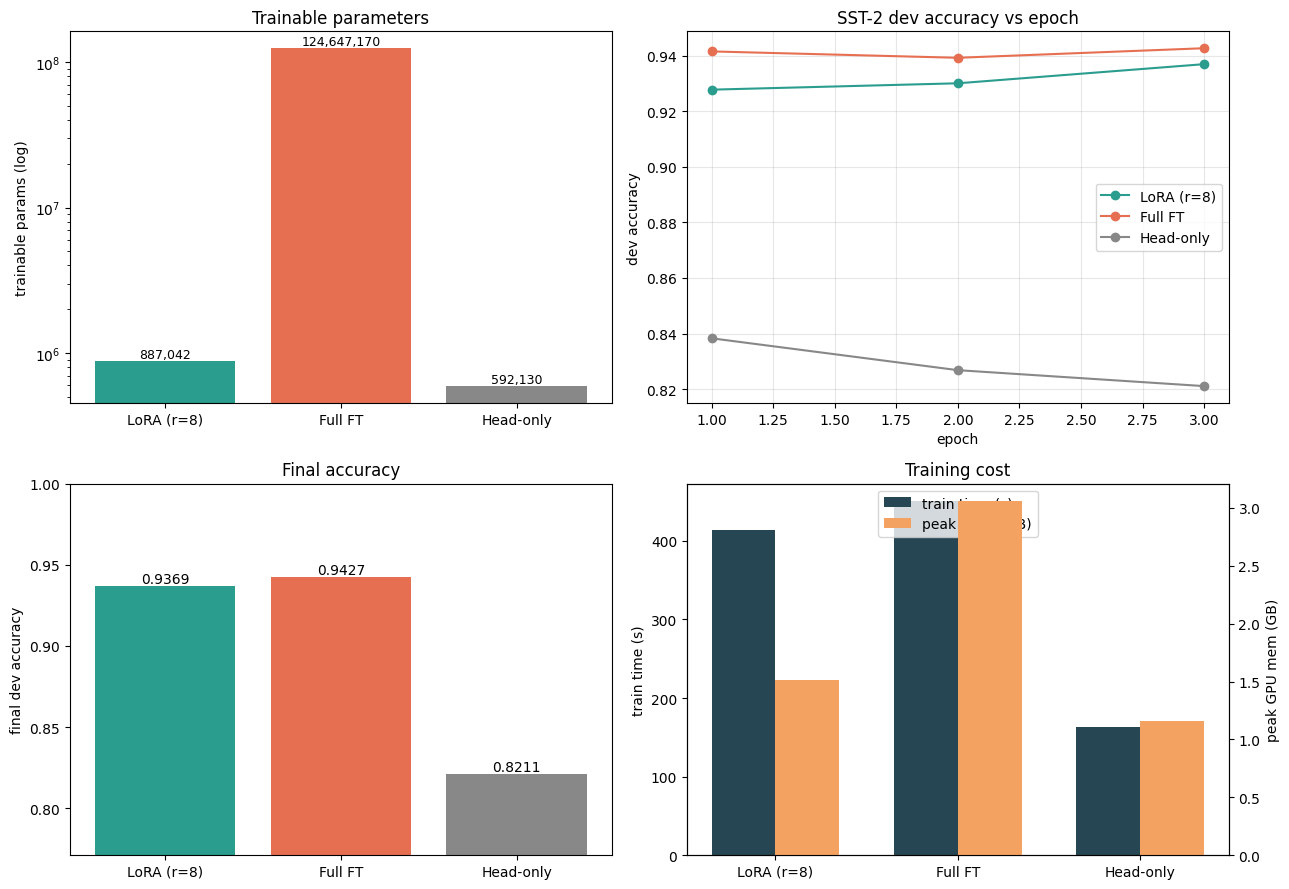

In [17]:
modes = ['lora', 'full', 'head']
colors = {'lora': '#2a9d8f', 'full': '#e76f51', 'head': '#888888'}
labels = {'lora': 'LoRA (r=8)', 'full': 'Full FT', 'head': 'Head-only'}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (a) trainable parameters — log scale
ax = axes[0, 0]
vals = [results[m]['trainable'] for m in modes]
ax.bar([labels[m] for m in modes], vals, color=[colors[m] for m in modes])
ax.set_yscale('log'); ax.set_ylabel('trainable params (log)')
ax.set_title('Trainable parameters')
for i, v in enumerate(vals):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

# (b) dev accuracy vs epoch
ax = axes[0, 1]
for m in modes:
    ax.plot(range(1, len(results[m]['history'])+1), results[m]['history'],
            marker='o', color=colors[m], label=labels[m])
ax.set_xlabel('epoch'); ax.set_ylabel('dev accuracy')
ax.set_title('SST-2 dev accuracy vs epoch'); ax.legend(); ax.grid(alpha=0.3)

# (c) final accuracy
ax = axes[1, 0]
vals = [results[m]['final_acc'] for m in modes]
bars = ax.bar([labels[m] for m in modes], vals, color=[colors[m] for m in modes])
ax.set_ylim(min(vals)-0.05, 1.0); ax.set_ylabel('final dev accuracy')
ax.set_title('Final accuracy')
for i, v in enumerate(vals):
    ax.text(i, v, f'{v:.4f}', ha='center', va='bottom', fontsize=10)

# (d) training time & peak memory
ax = axes[1, 1]
x = np.arange(len(modes)); w = 0.35
t = [results[m]['time_s'] for m in modes]
mem = [results[m]['peak_mem_gb'] for m in modes]
ax.bar(x - w/2, t, w, label='train time (s)', color='#264653')
ax2 = ax.twinx()
ax2.bar(x + w/2, mem, w, label='peak mem (GB)', color='#f4a261')
ax.set_xticks(x); ax.set_xticklabels([labels[m] for m in modes])
ax.set_ylabel('train time (s)'); ax2.set_ylabel('peak GPU mem (GB)')
ax.set_title('Training cost')
lines1, lab1 = ax.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, lab1+lab2, loc='upper center')

plt.tight_layout(); plt.show()

## 8. Takeaways

Compare against the paper's central result (Table 2): on RoBERTa-base, LoRA matches full fine-tuning
while training ~0.3M params instead of 125M (~0.24%). The accuracy gap you observe here will be
smaller than the paper's because we run far fewer epochs (3 vs 60) and a shorter sequence length —
but the parameter-efficiency story (the bar chart in 7a) reproduces exactly.

**To get closer to the paper's numbers:** set `cfg.epochs = 60`, `cfg.max_seq_len = 512`, and average
over several seeds (expect a long T4 run).